Cell 1 – Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

Cell 2 – Load and Preprocess the Dataset

In [2]:
# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize
x_test = x_test.astype("float32") / 255.0

# Reshape
x_test = x_test.reshape(-1, 28, 28, 1)

# Keep original labels
y_true = y_test

# One-hot encoding (optional)
y_test = to_categorical(y_test, 10)

print("Test dataset loaded successfully.")

Test dataset loaded successfully.


Cell 3 – Load the Trained Model

In [3]:
model = load_model("saved_model/mnist_cnn_model.h5")

print("Model loaded successfully.")

Model loaded successfully.


Cell 4 – Predict Test Images

In [4]:
predictions = model.predict(x_test)

y_pred = np.argmax(predictions, axis=1)

print("Prediction completed.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Prediction completed.


Cell 5 – Calculate Accuracy

In [5]:
accuracy = accuracy_score(y_true, y_pred)

print("=" * 50)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print("=" * 50)

Test Accuracy: 99.21%


Cell 6 – Classification Report

In [6]:
print("Classification Report\n")

print(classification_report(y_true, y_pred))

Classification Report

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       1.00      0.98      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



Cell 7 – Confusion Matrix

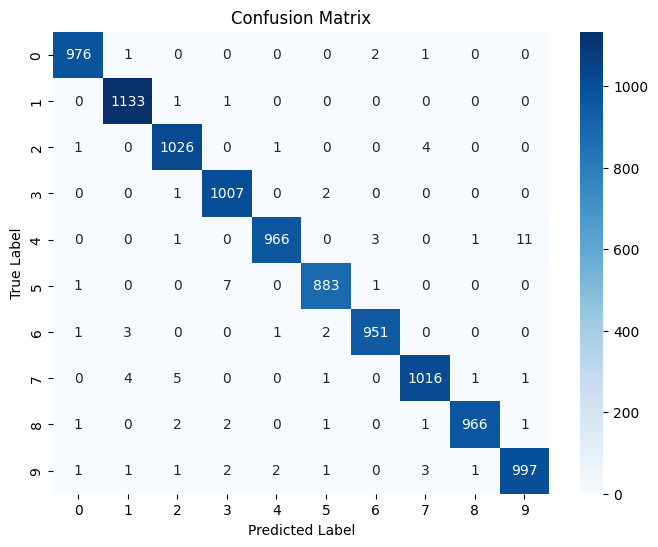

In [7]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

os.makedirs("results", exist_ok=True)

plt.savefig("results/confusion_matrix.png")

plt.show()

Cell 8 – Display Sample Predictions

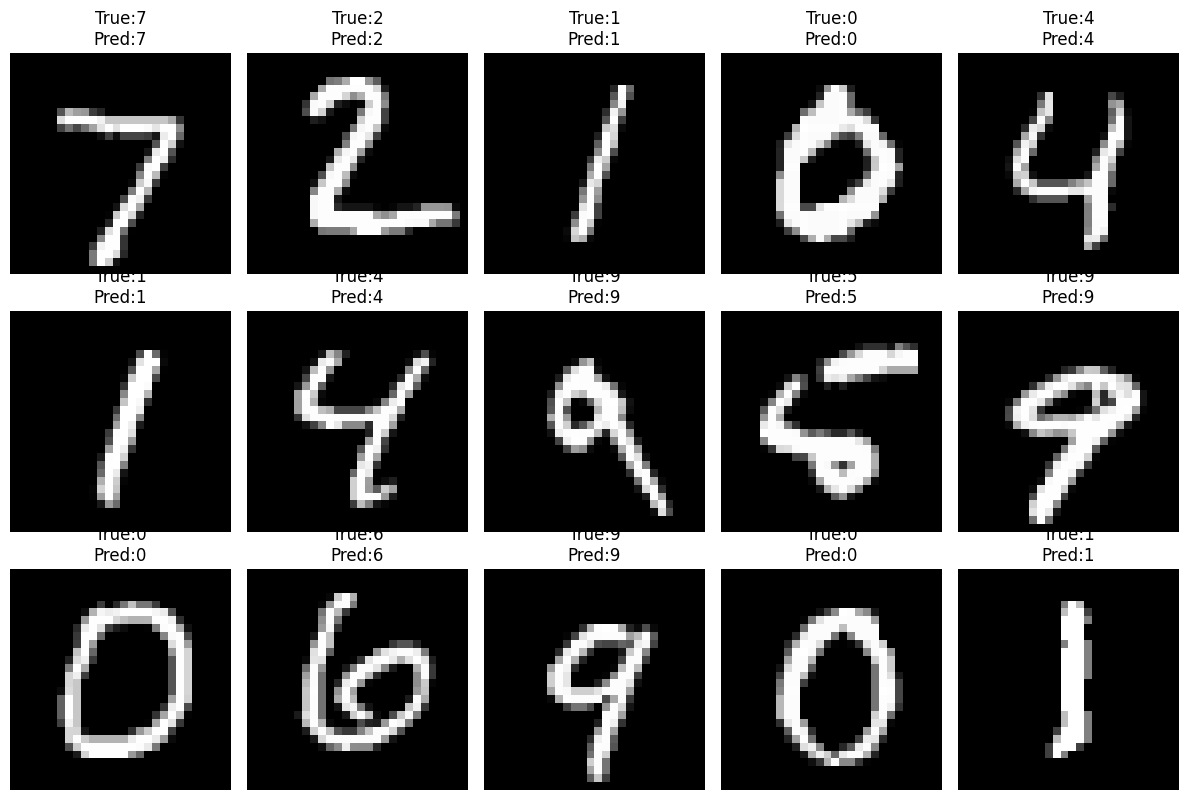

In [8]:
plt.figure(figsize=(12,8))

for i in range(15):

    plt.subplot(3,5,i+1)

    plt.imshow(x_test[i].reshape(28,28), cmap='gray')

    plt.title(f"True:{y_true[i]}\nPred:{y_pred[i]}")

    plt.axis('off')

plt.tight_layout()

plt.show()

Cell 9 – Show Correct and Incorrect Predictions

In [9]:
correct = np.sum(y_true == y_pred)
incorrect = np.sum(y_true != y_pred)

print(f"Correct Predictions : {correct}")
print(f"Incorrect Predictions : {incorrect}")

Correct Predictions : 9921
Incorrect Predictions : 79
